In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Lectura Excel 

df = pd.read_excel(r"C:/Rosi/THERMECOWAT/260324_CdM_chemical_data_shiny_TEW.xlsx")
df.tail(7)


,nom definitiu plantilla,IDEH,Origen,Toponim,latitud,longitud,Altitud,Municipi,TipusPunt,EstatPunt,...,K_ppm,Cl_ppm,HCO3_ppm,SO4_ppm,NO3_ppm,NH4_ppm,NO2_ppm,PO4_ppm,CO3_ppm,SiO2_ppm
44,NaN,CdM_093,202601ALS,Riera 2,41.650794,2.154177,240.1,Caldes de Montbui,River,NaN,...,3.2,37.2,343,67.9,2.57,0.025,0.03,0.5,7.92,10.1
45,NaN,CdM_001,202601ALS,Pou termal - Caldes de Montbui,41.634452,2.162169,207.7,Caldes de Montbui,Groundwater,NaN,...,17.5,457,168,61.4,0.1,0.613,0.075,0.02,0,79.4
46,NaN,CdM_084,202601ALS,POU FONT ENAMORATS 5 - AJMT CALDES MONTBUI (GM...,41.655351,2.175087,383.4,Caldes de Montbui,Groundwater,NaN,...,3.88,61.8,364,76.6,54.4,0.025,0.03,0.02,0,18.3
47,NaN,CdM_082,202601ALS,POU CAN CAMP - AJMT. CALDES MONTBUI (GMSSA),41.647619,2.17838,336.8,Caldes de Montbui,Groundwater,NaN,...,1.99,61.9,334,73.4,42.7,0.025,0.02,0.02,0,22.1
48,NaN,CdM_073,202601ALS,Pou POU 4 (BORDA CASETA) - GERMÀ CHAFFARD / AJ...,41.635296,2.17688,229.9,Caldes de Montbui,Groundwater,NaN,...,2.19,50.1,343,78.5,97.9,0.025,0.03,0.02,0,20.7
49,NaN,CdM_088,202601ALS,Font Del Gorg D'En Pèlags,41.636711,2.144912,286.5,Caldes de Montbui,Spring,NaN,...,4.96,45.6,466,140,3.5,0.025,0.03,0.02,0,9.89
50,NaN,CdM_093,202601ALS,Riera 2,41.650794,2.154177,240.1,Caldes de Montbui,River,NaN,...,2.61,33.5,363,50.5,11.2,0.025,0.02,0.595,9.36,5.9


In [2]:

# 1. Convierto columnas a numéricas
df["Ca_ppm"] = pd.to_numeric(df["Ca_ppm"], errors='coerce')
df["Na_ppm"] = pd.to_numeric(df["Na_ppm"], errors='coerce')
df["HCO3_ppm"] = pd.to_numeric(df["HCO3_ppm"], errors='coerce')
df["Cl_ppm"] = pd.to_numeric(df["Cl_ppm"], errors='coerce')

# 2. Pesos equivalentes
eq_HCO3 = 61.0       # HCO3-, valencia 1
eq_Na   = 23.0       # Na+, valencia 1
eq_Ca   = 20.04      # Ca2+, valencia 2
eq_Cl = 35.453   # Cl-, valencia 1

# 3. Convierto mg/L → meq/L
df["HCO3_meq"] = df["HCO3_ppm"] / eq_HCO3
df["Na_meq"]   = df["Na_ppm"]   / eq_Na
df["Ca_meq"]   = df["Ca_ppm"]   / eq_Ca
df["Cl_meq"]   = df["Cl_ppm"]   / eq_Cl

df.tail(6)

,nom definitiu plantilla,IDEH,Origen,Toponim,latitud,longitud,Altitud,Municipi,TipusPunt,EstatPunt,...,NO3_ppm,NH4_ppm,NO2_ppm,PO4_ppm,CO3_ppm,SiO2_ppm,HCO3_meq,Na_meq,Ca_meq,Cl_meq
45,NaN,CdM_001,202601ALS,Pou termal - Caldes de Montbui,41.634452,2.162169,207.7,Caldes de Montbui,Groundwater,NaN,...,0.1,0.613,0.075,0.02,0,79.4,2.754098,15.956522,1.327345,12.890305
46,NaN,CdM_084,202601ALS,POU FONT ENAMORATS 5 - AJMT CALDES MONTBUI (GM...,41.655351,2.175087,383.4,Caldes de Montbui,Groundwater,NaN,...,54.4,0.025,0.03,0.02,0,18.3,5.967213,1.169565,6.237525,1.743153
47,NaN,CdM_082,202601ALS,POU CAN CAMP - AJMT. CALDES MONTBUI (GMSSA),41.647619,2.17838,336.8,Caldes de Montbui,Groundwater,NaN,...,42.7,0.025,0.02,0.02,0,22.1,5.475410,1.226087,5.588822,1.745974
48,NaN,CdM_073,202601ALS,Pou POU 4 (BORDA CASETA) - GERMÀ CHAFFARD / AJ...,41.635296,2.17688,229.9,Caldes de Montbui,Groundwater,NaN,...,97.9,0.025,0.03,0.02,0,20.7,5.622951,1.060870,6.586826,1.413139
49,NaN,CdM_088,202601ALS,Font Del Gorg D'En Pèlags,41.636711,2.144912,286.5,Caldes de Montbui,Spring,NaN,...,3.5,0.025,0.03,0.02,0,9.89,7.639344,0.882609,6.237525,1.286210
50,NaN,CdM_093,202601ALS,Riera 2,41.650794,2.154177,240.1,Caldes de Montbui,River,NaN,...,11.2,0.025,0.02,0.595,9.36,5.9,5.950820,0.682609,4.346307,0.944913


## Gaillarde Diagram
El área del punto final de la disolución de evaporitas en algunas referencias puede variar dependiendo de si se está analizando aguas superficiales o subterráneas.
1. Aguas superficiales: Ca/Na suele oscilar entre 0.1–1 y HCO₃/Na entre 0.1–1 (zona en la representación con vértice inferior izquierda en x= 0.1, y = 0.1)
2. Aguas subterráneas: Ca/Na puede caer por debajo de 0.05 y HCO₃/Na puede ser <0.1 (por esto, la zona se desplaza hacia abajo en x= 0.01, y=0.01)

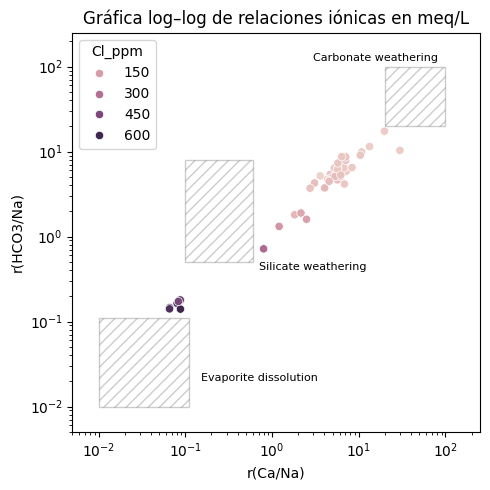

In [ ]:
import seaborn as sns 
import matplotlib.patches as mpatches

#  4. Calculo ratios
df["r_HCO3_Na"] = df["HCO3_meq"] / df["Na_meq"]
df["r_Ca_Na"]   = df["Ca_meq"]   / df["Na_meq"]


#  5. Gráfica log–log 
def plot_Gaillarde(df, hue):
    fig_Gai=plt.figure(figsize=(5,5))

    sns.scatterplot(data= df, 
                x= 'r_Ca_Na',
                y= 'r_HCO3_Na',
                hue= hue,
                )

    # añado rectángulo para evaporitas
    rect_evap = mpatches.Rectangle([0.01, 0.01], 0.1, 0.1, 
                              fc="w", ec='k', alpha=0.2, hatch='///')
    plt.gca().add_patch(rect_evap)
    plt.text(0.15, 0.02, 'Evaporite dissolution', fontsize=8)

    # Añado rectángulo para silicatos
    rect_sil = mpatches.Rectangle([0.1, 0.5], 0.5, 7.5, 
                              fc="w", ec='k', alpha=0.2, hatch='///')
    plt.gca().add_patch(rect_sil)
    plt.text(0.7, 0.4, 'Silicate weathering', fontsize=8)

    # Añado rectángulo para carbonatos

    rect_carb = mpatches.Rectangle([20, 20], 80, 80,
                                   fc="w", ec='k', alpha=0.2, hatch='///')
    plt.gca().add_patch(rect_carb)
    plt.text(3, 115, 'Carbonate weathering', fontsize=8)


    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(0.005, 250)
    plt.ylim(0.005, 250)
    plt.xlabel("r(Ca/Na)")
    plt.ylabel("r(HCO3/Na)")
    plt.title("Gráfica log–log de relaciones iónicas en meq/L")

    #plt.grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    return
plot_Gaillarde(df, hue='Cl_ppm')

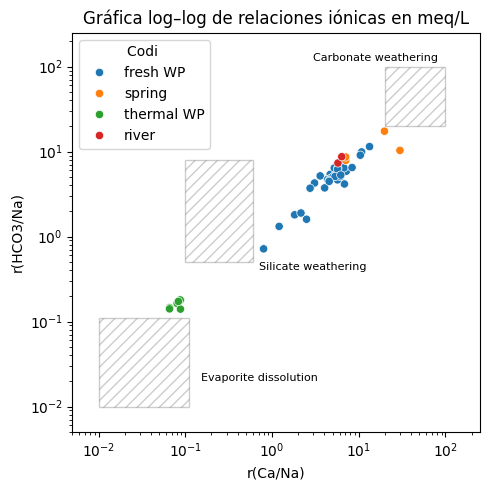

In [6]:
plot_Gaillarde(df, hue='Codi ')

In [7]:
print(df.columns.tolist())

['nom definitiu plantilla', 'IDEH', 'Origen', 'Toponim', 'latitud', 'longitud', 'Altitud', 'Municipi', 'TipusPunt', 'EstatPunt', 'ProfunditatPou', 'Codi ', 'Descripcio', 'UsPunt', 'Temperatura_C', 'ProfunditatNP', 'DataMostreig', 'CE_microS_cm', 'pH', 'ORP_mV', 'Ca_ppm', 'Mg_ppm', 'Na_ppm', 'K_ppm', 'Cl_ppm', 'HCO3_ppm', 'SO4_ppm', 'NO3_ppm', 'NH4_ppm', 'NO2_ppm', 'PO4_ppm', 'CO3_ppm', 'SiO2_ppm', 'HCO3_meq', 'Na_meq', 'Ca_meq', 'Cl_meq', 'r_HCO3_Na', 'r_Ca_Na']


In [8]:
# Dejo solo los puntos con analíticas en Diciembre de 2026
df_dic26 = df.iloc[32:]
df_dic26

,nom definitiu plantilla,IDEH,Origen,Toponim,latitud,longitud,Altitud,Municipi,TipusPunt,EstatPunt,...,NO2_ppm,PO4_ppm,CO3_ppm,SiO2_ppm,HCO3_meq,Na_meq,Ca_meq,Cl_meq,r_HCO3_Na,r_Ca_Na
38,NaN,CdM_001,202601ALS,Pou termal,41.634452,2.162169,207.7,Caldes de Montbui,Groundwater,NaN,...,0.075,0.02,0,90.9,2.655738,15.000000,1.317365,14.610893,0.177049,0.087824
39,NaN,CdM_084,202601ALS,POU FONT ENAMORATS,41.655351,2.175087,383.4,Caldes de Montbui,Groundwater,NaN,...,0.03,0.02,0,21.5,5.983607,1.186957,5.988024,1.841875,5.041134,5.044855
40,NaN,CdM_082,202601ALS,POU CAN CAMP,41.647619,2.17838,336.8,Caldes de Montbui,Groundwater,NaN,...,0.03,0.02,0,26.1,5.606557,1.230435,5.588822,1.686740,4.556566,4.542152
41,NaN,CdM_073,202601ALS,Pou BORDA CASETA),41.635296,2.17688,229.9,Caldes de Montbui,Groundwater,NaN,...,0.03,0.02,1.32,23.9,5.180328,1.017391,6.237525,1.551350,5.091775,6.130901
42,NaN,CdM_091,202601ALS,Pou termal Curt,41.634508,2.161378,207.5,Caldes de Montbui,Groundwater,NaN,...,0.075,0.02,1.08,87.8,2.688525,14.956522,1.307385,14.667306,0.179756,0.087412
43,NaN,CdM_088,202601ALS,Font Del Gorg D'En Pèlags,41.636711,2.144912,286.5,Caldes de Montbui,Spring,NaN,...,0.03,0.02,0,10.8,7.180328,0.908696,6.437126,1.286210,7.901796,7.083918
44,NaN,CdM_093,202601ALS,Riera 2,41.650794,2.154177,240.1,Caldes de Montbui,River,NaN,...,0.03,0.5,7.92,10.1,5.622951,0.765217,4.401198,1.049277,7.348174,5.751565
45,NaN,CdM_001,202601ALS,Pou termal - Caldes de Montbui,41.634452,2.162169,207.7,Caldes de Montbui,Groundwater,NaN,...,0.075,0.02,0,79.4,2.754098,15.956522,1.327345,12.890305,0.172600,0.083185
46,NaN,CdM_084,202601ALS,POU FONT ENAMORATS 5 - AJMT CALDES MONTBUI (GM...,41.655351,2.175087,383.4,Caldes de Montbui,Groundwater,NaN,...,0.03,0.02,0,18.3,5.967213,1.169565,6.237525,1.743153,5.102078,5.333200
47,NaN,CdM_082,202601ALS,POU CAN CAMP - AJMT. CALDES MONTBUI (GMSSA),41.647619,2.17838,336.8,Caldes de Montbui,Groundwater,NaN,...,0.02,0.02,0,22.1,5.475410,1.226087,5.588822,1.745974,4.465760,4.558259


In [9]:
# Genero un numeo dataframe con los puntos de la campaña de Dic 2026
df_dic26 = df_dic26.copy() # .copy() después de hacer filtros, para dejar claro que estoy trabajando sobre esta parte y no sobre el dataframe anterior.



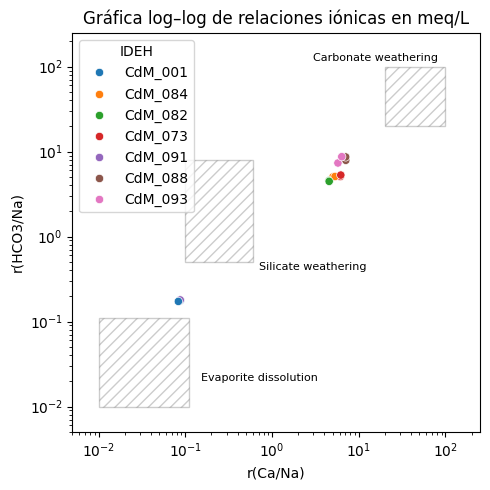

In [10]:
plot_Gaillarde(df_dic26, hue='IDEH')

In [11]:
df_dic26

,nom definitiu plantilla,IDEH,Origen,Toponim,latitud,longitud,Altitud,Municipi,TipusPunt,EstatPunt,...,NO2_ppm,PO4_ppm,CO3_ppm,SiO2_ppm,HCO3_meq,Na_meq,Ca_meq,Cl_meq,r_HCO3_Na,r_Ca_Na
38,NaN,CdM_001,202601ALS,Pou termal,41.634452,2.162169,207.7,Caldes de Montbui,Groundwater,NaN,...,0.075,0.02,0,90.9,2.655738,15.000000,1.317365,14.610893,0.177049,0.087824
39,NaN,CdM_084,202601ALS,POU FONT ENAMORATS,41.655351,2.175087,383.4,Caldes de Montbui,Groundwater,NaN,...,0.03,0.02,0,21.5,5.983607,1.186957,5.988024,1.841875,5.041134,5.044855
40,NaN,CdM_082,202601ALS,POU CAN CAMP,41.647619,2.17838,336.8,Caldes de Montbui,Groundwater,NaN,...,0.03,0.02,0,26.1,5.606557,1.230435,5.588822,1.686740,4.556566,4.542152
41,NaN,CdM_073,202601ALS,Pou BORDA CASETA),41.635296,2.17688,229.9,Caldes de Montbui,Groundwater,NaN,...,0.03,0.02,1.32,23.9,5.180328,1.017391,6.237525,1.551350,5.091775,6.130901
42,NaN,CdM_091,202601ALS,Pou termal Curt,41.634508,2.161378,207.5,Caldes de Montbui,Groundwater,NaN,...,0.075,0.02,1.08,87.8,2.688525,14.956522,1.307385,14.667306,0.179756,0.087412
43,NaN,CdM_088,202601ALS,Font Del Gorg D'En Pèlags,41.636711,2.144912,286.5,Caldes de Montbui,Spring,NaN,...,0.03,0.02,0,10.8,7.180328,0.908696,6.437126,1.286210,7.901796,7.083918
44,NaN,CdM_093,202601ALS,Riera 2,41.650794,2.154177,240.1,Caldes de Montbui,River,NaN,...,0.03,0.5,7.92,10.1,5.622951,0.765217,4.401198,1.049277,7.348174,5.751565
45,NaN,CdM_001,202601ALS,Pou termal - Caldes de Montbui,41.634452,2.162169,207.7,Caldes de Montbui,Groundwater,NaN,...,0.075,0.02,0,79.4,2.754098,15.956522,1.327345,12.890305,0.172600,0.083185
46,NaN,CdM_084,202601ALS,POU FONT ENAMORATS 5 - AJMT CALDES MONTBUI (GM...,41.655351,2.175087,383.4,Caldes de Montbui,Groundwater,NaN,...,0.03,0.02,0,18.3,5.967213,1.169565,6.237525,1.743153,5.102078,5.333200
47,NaN,CdM_082,202601ALS,POU CAN CAMP - AJMT. CALDES MONTBUI (GMSSA),41.647619,2.17838,336.8,Caldes de Montbui,Groundwater,NaN,...,0.02,0.02,0,22.1,5.475410,1.226087,5.588822,1.745974,4.465760,4.558259


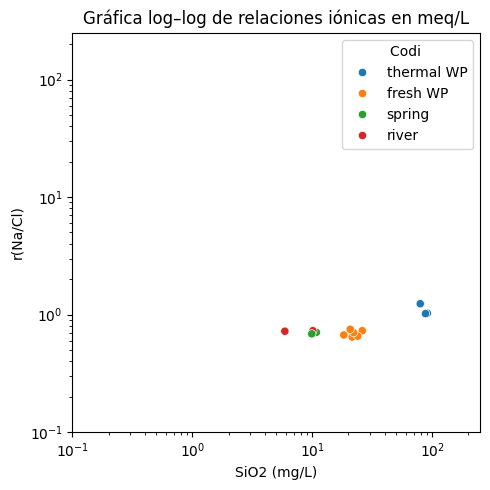

In [12]:
# Comprobar si el Na y la SiO2 provienen de la alteración de silicatos
# según mi gráfico el agua termal está muy poco por encima de la lína de rNa/Cl = 1 y muy alejada de la línea de disolución de albita. Ver figura de referencia
# Por lo tanto la alteración de silicatos es décil. Confirmado también por el diagrama de relación iónica, HCO3/Na vs Ca/Na
# El SiO2 puede tener otros origenes que no sean la disolución de silicatos: 
# 1. aportes hidrotermalaes profundos disuelto desde el basamento o zonas metamórficas
# 2. Asociados a fallas activas.
# Tenemos indicadores de profundidad como son Li y otros pero que no implican alteración de albita
# el Li alto indica tiempo de residencia alto, temperaturas altas, interacción con micas/arcillas profundas. 
fig_Albita=plt.figure(figsize=(5,5))
df_dic26["r_Na_Cl"] = df_dic26["Na_meq"] / df_dic26["Cl_meq"]
sns.scatterplot(data= df_dic26, 
                x= 'SiO2_ppm',
                y= 'r_Na_Cl',
                hue= "Codi ",
                )


plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1, 250)
plt.ylim(0.1, 250)
plt.ylabel("r(Na/Cl)")
plt.xlabel("SiO2 (mg/L)")
plt.title("Gráfica log–log de relaciones iónicas en meq/L")
#plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()

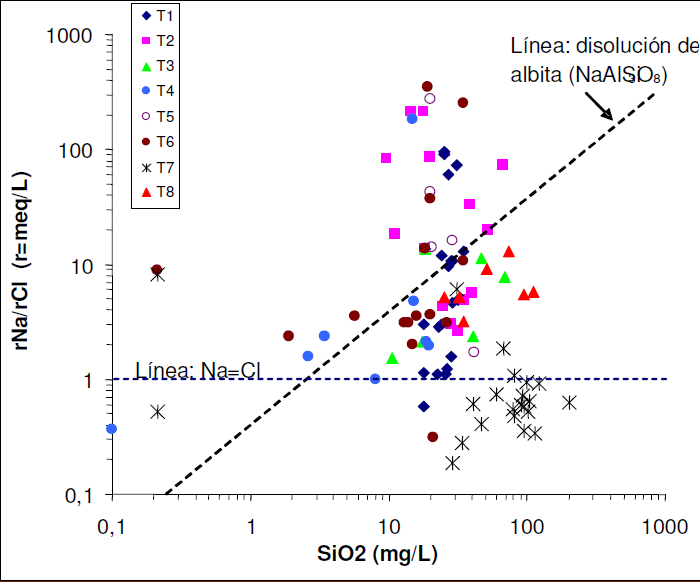

In [13]:
from IPython.display import Image
Image(r"figures/rNa_Cl_vs_SiO2_albita.png")